In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

print("Project root:", os.getcwd())

Project root: C:\Users\user\Desktop\Plant_Stress_Domain_Shift


In [2]:
metrics_path = "results/mobilenetv3_small_all_dataset_metrics_comparison.csv"

all_metrics = pd.read_csv(metrics_path)

print(all_metrics)

  train_dataset             test_dataset              model  accuracy  \
0  PlantVillage  PlantVillage_validation  MobileNetV3-Small  0.962500   
1  PlantVillage                 PlantDoc  MobileNetV3-Small  0.744168   
2  PlantVillage       PlantPathology2020  MobileNetV3-Small  0.734212   

   precision   recall  f1_score   roc_auc  
0   1.000000  0.92500  0.961039  0.997075  
1   0.752963  0.92058  0.828378  0.718911  
2   0.807031  0.82682  0.816805  0.723522  


In [3]:
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights
from PIL import Image

from sklearn.metrics import brier_score_loss

print("Uncertainty libraries ready.")

Uncertainty libraries ready.


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = MobileNet_V3_Small_Weights.DEFAULT
model = mobilenet_v3_small(weights=weights)

for param in model.features.parameters():
    param.requires_grad = False

model.classifier[3] = nn.Linear(model.classifier[3].in_features, 2)

model_path = "models/mobilenetv3_small_plantvillage_sample.pth"
model.load_state_dict(torch.load(model_path, map_location=device))

model = model.to(device)
model.eval()

print("Device:", device)
print("Model loaded successfully.")

Device: cpu
Model loaded successfully.


In [5]:
image_size = 224

val_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class PlantStressDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        image_path = self.dataframe.loc[index, "image_path"]
        label = int(self.dataframe.loc[index, "label"])

        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, label

print("Transform and Dataset class ready.")

Transform and Dataset class ready.


In [6]:
from sklearn.model_selection import train_test_split

plantvillage_csv = "data/PlantVillage/plantvillage_binary_metadata.csv"

df = pd.read_csv(plantvillage_csv)

label_map = {
    "Healthy": 0,
    "Stressed/Diseased": 1
}

df["label"] = df["binary_label"].map(label_map)

df_sample = (
    df.groupby("label", group_keys=False)
    .apply(lambda x: x.sample(n=1000, random_state=42))
    .reset_index(drop=True)
)

train_df, val_df = train_test_split(
    df_sample,
    test_size=0.2,
    random_state=42,
    stratify=df_sample["label"]
)

print("Validation size:", len(val_df))
print(val_df["binary_label"].value_counts())

KeyError: 'label'

In [7]:
from sklearn.model_selection import train_test_split

plantvillage_csv = "data/PlantVillage/plantvillage_binary_metadata.csv"

df = pd.read_csv(plantvillage_csv)

label_map = {
    "Healthy": 0,
    "Stressed/Diseased": 1
}

df["label"] = df["binary_label"].map(label_map)

df_healthy = df[df["label"] == 0].sample(n=1000, random_state=42)
df_stressed = df[df["label"] == 1].sample(n=1000, random_state=42)

df_sample = pd.concat([df_healthy, df_stressed]).reset_index(drop=True)

df_sample["label"] = df_sample["binary_label"].map(label_map)

train_df, val_df = train_test_split(
    df_sample,
    test_size=0.2,
    random_state=42,
    stratify=df_sample["label"]
)

print("Validation size:", len(val_df))
print(val_df["binary_label"].value_counts())
print(val_df["label"].value_counts())

Validation size: 400
binary_label
Healthy              200
Stressed/Diseased    200
Name: count, dtype: int64
label
0    200
1    200
Name: count, dtype: int64


In [8]:
def get_predictions_and_probabilities(dataframe, batch_size=16):
    dataset = PlantStressDataset(
        dataframe,
        transform=val_transform
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False
    )

    all_labels = []
    all_predictions = []
    all_probabilities = []

    model.eval()

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probabilities = torch.softmax(outputs, dim=1)
            predictions = torch.argmax(probabilities, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())
            all_probabilities.extend(probabilities[:, 1].cpu().numpy())

    return (
        np.array(all_labels),
        np.array(all_predictions),
        np.array(all_probabilities)
    )

print("Prediction function ready.")

Prediction function ready.


In [9]:
pv_labels, pv_predictions, pv_probabilities = get_predictions_and_probabilities(val_df)

print("PlantVillage validation probabilities ready.")
print("Number of samples:", len(pv_labels))
print("First 10 probabilities:", pv_probabilities[:10])

PlantVillage validation probabilities ready.
Number of samples: 400
First 10 probabilities: [1.2140054e-02 5.2516870e-03 9.9958831e-01 6.7181081e-02 2.4934136e-04
 9.9991071e-01 7.9872364e-01 7.8488997e-04 1.4978050e-02 9.9996138e-01]


In [10]:
plantdoc_df = pd.read_csv("data/PlantDoc/plantdoc_binary_metadata.csv")
pp2020_df = pd.read_csv("data/PlantPathology2020/plantpathology2020_binary_metadata.csv")

label_map = {
    "Healthy": 0,
    "Stressed/Diseased": 1
}

plantdoc_df["label"] = plantdoc_df["binary_label"].map(label_map)
pp2020_df["label"] = pp2020_df["binary_label"].map(label_map)

print("PlantDoc:", len(plantdoc_df))
print(plantdoc_df["binary_label"].value_counts())

print("\nPlant Pathology 2020:", len(pp2020_df))
print(pp2020_df["binary_label"].value_counts())

PlantDoc: 2572
binary_label
Stressed/Diseased    1725
Healthy               847
Name: count, dtype: int64

Plant Pathology 2020: 1821
binary_label
Stressed/Diseased    1305
Healthy               516
Name: count, dtype: int64


In [11]:
PlantDoc: 2572
binary_label
Stressed/Diseased    1725
Healthy               847
Name: count, dtype: int64

Plant Pathology 2020: 1821
binary_label
Stressed/Diseased    1305
Healthy               516
Name: count, dtype: int64

SyntaxError: invalid syntax (2693582520.py, line 3)

In [12]:
plantdoc_df = pd.read_csv("data/PlantDoc/plantdoc_binary_metadata.csv")
pp2020_df = pd.read_csv("data/PlantPathology2020/plantpathology2020_binary_metadata.csv")

label_map = {
    "Healthy": 0,
    "Stressed/Diseased": 1
}

plantdoc_df["label"] = plantdoc_df["binary_label"].map(label_map)
pp2020_df["label"] = pp2020_df["binary_label"].map(label_map)

print("PlantDoc:", len(plantdoc_df))
print(plantdoc_df["binary_label"].value_counts())

print("\nPlant Pathology 2020:", len(pp2020_df))
print(pp2020_df["binary_label"].value_counts())

PlantDoc: 2572
binary_label
Stressed/Diseased    1725
Healthy               847
Name: count, dtype: int64

Plant Pathology 2020: 1821
binary_label
Stressed/Diseased    1305
Healthy               516
Name: count, dtype: int64


In [13]:
plantdoc_labels, plantdoc_predictions, plantdoc_probabilities = get_predictions_and_probabilities(plantdoc_df)

print("PlantDoc probabilities ready.")
print("Number of samples:", len(plantdoc_labels))
print("First 10 probabilities:", plantdoc_probabilities[:10])

PlantDoc probabilities ready.
Number of samples: 2572
First 10 probabilities: [0.9997899  0.9999192  0.99838257 0.9883866  0.9954371  0.9931244
 0.820748   0.9867972  0.9919361  0.9918685 ]


In [14]:
pp2020_labels, pp2020_predictions, pp2020_probabilities = get_predictions_and_probabilities(pp2020_df)

print("Plant Pathology 2020 probabilities ready.")
print("Number of samples:", len(pp2020_labels))
print("First 10 probabilities:", pp2020_probabilities[:10])

Plant Pathology 2020 probabilities ready.
Number of samples: 1821
First 10 probabilities: [0.9937697  0.99999964 0.71228945 0.7982101  0.16530223 0.36567247
 0.2284172  0.9687264  0.4974262  0.83088744]


In [15]:
from sklearn.metrics import brier_score_loss

pv_brier = brier_score_loss(pv_labels, pv_probabilities)
plantdoc_brier = brier_score_loss(plantdoc_labels, plantdoc_probabilities)
pp2020_brier = brier_score_loss(pp2020_labels, pp2020_probabilities)

print("Brier score")
print("PlantVillage validation:", pv_brier)
print("PlantDoc:", plantdoc_brier)
print("Plant Pathology 2020:", pp2020_brier)

Brier score
PlantVillage validation: 0.029080763459205627
PlantDoc: 0.21667072176933289
Plant Pathology 2020: 0.2026524841785431


In [16]:
brier_results = pd.DataFrame([
    {
        "train_dataset": "PlantVillage",
        "test_dataset": "PlantVillage_validation",
        "model": "MobileNetV3-Small",
        "brier_score": pv_brier
    },
    {
        "train_dataset": "PlantVillage",
        "test_dataset": "PlantDoc",
        "model": "MobileNetV3-Small",
        "brier_score": plantdoc_brier
    },
    {
        "train_dataset": "PlantVillage",
        "test_dataset": "PlantPathology2020",
        "model": "MobileNetV3-Small",
        "brier_score": pp2020_brier
    }
])

brier_path = "results/mobilenetv3_small_brier_scores.csv"

brier_results.to_csv(brier_path, index=False)

print("Brier scores saved at:", brier_path)
print(brier_results)

Brier scores saved at: results/mobilenetv3_small_brier_scores.csv
  train_dataset             test_dataset              model  brier_score
0  PlantVillage  PlantVillage_validation  MobileNetV3-Small     0.029081
1  PlantVillage                 PlantDoc  MobileNetV3-Small     0.216671
2  PlantVillage       PlantPathology2020  MobileNetV3-Small     0.202652


In [17]:
def expected_calibration_error(labels, probabilities, n_bins=10):
    labels = np.array(labels)
    probabilities = np.array(probabilities)

    predictions = (probabilities >= 0.5).astype(int)
    confidences = np.where(predictions == 1, probabilities, 1 - probabilities)
    correctness = (predictions == labels).astype(int)

    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        bin_lower = bin_boundaries[i]
        bin_upper = bin_boundaries[i + 1]

        in_bin = (confidences > bin_lower) & (confidences <= bin_upper)
        prop_in_bin = np.mean(in_bin)

        if prop_in_bin > 0:
            accuracy_in_bin = np.mean(correctness[in_bin])
            confidence_in_bin = np.mean(confidences[in_bin])
            ece += prop_in_bin * abs(accuracy_in_bin - confidence_in_bin)

    return ece

print("ECE function ready.")

ECE function ready.


In [18]:
pv_ece = expected_calibration_error(pv_labels, pv_probabilities, n_bins=10)
plantdoc_ece = expected_calibration_error(plantdoc_labels, plantdoc_probabilities, n_bins=10)
pp2020_ece = expected_calibration_error(pp2020_labels, pp2020_probabilities, n_bins=10)

print("Expected Calibration Error")
print("PlantVillage validation:", pv_ece)
print("PlantDoc:", plantdoc_ece)
print("Plant Pathology 2020:", pp2020_ece)

Expected Calibration Error
PlantVillage validation: 0.01249585717916489
PlantDoc: 0.17552071587294105
Plant Pathology 2020: 0.14359549664979715


In [19]:
ece_results = pd.DataFrame([
    {
        "train_dataset": "PlantVillage",
        "test_dataset": "PlantVillage_validation",
        "model": "MobileNetV3-Small",
        "ece": pv_ece
    },
    {
        "train_dataset": "PlantVillage",
        "test_dataset": "PlantDoc",
        "model": "MobileNetV3-Small",
        "ece": plantdoc_ece
    },
    {
        "train_dataset": "PlantVillage",
        "test_dataset": "PlantPathology2020",
        "model": "MobileNetV3-Small",
        "ece": pp2020_ece
    }
])

ece_path = "results/mobilenetv3_small_ece_scores.csv"

ece_results.to_csv(ece_path, index=False)

print("ECE scores saved at:", ece_path)
print(ece_results)

ECE scores saved at: results/mobilenetv3_small_ece_scores.csv
  train_dataset             test_dataset              model       ece
0  PlantVillage  PlantVillage_validation  MobileNetV3-Small  0.012496
1  PlantVillage                 PlantDoc  MobileNetV3-Small  0.175521
2  PlantVillage       PlantPathology2020  MobileNetV3-Small  0.143595


In [20]:
combined_results = all_metrics.merge(
    brier_results[["test_dataset", "brier_score"]],
    on="test_dataset",
    how="left"
)

combined_results = combined_results.merge(
    ece_results[["test_dataset", "ece"]],
    on="test_dataset",
    how="left"
)

combined_path = "results/mobilenetv3_small_performance_uncertainty_summary.csv"

combined_results.to_csv(combined_path, index=False)

print("Combined results saved at:", combined_path)
print(combined_results)

Combined results saved at: results/mobilenetv3_small_performance_uncertainty_summary.csv
  train_dataset             test_dataset              model  accuracy  \
0  PlantVillage  PlantVillage_validation  MobileNetV3-Small  0.962500   
1  PlantVillage                 PlantDoc  MobileNetV3-Small  0.744168   
2  PlantVillage       PlantPathology2020  MobileNetV3-Small  0.734212   

   precision   recall  f1_score   roc_auc  brier_score       ece  
0   1.000000  0.92500  0.961039  0.997075     0.029081  0.012496  
1   0.752963  0.92058  0.828378  0.718911     0.216671  0.175521  
2   0.807031  0.82682  0.816805  0.723522     0.202652  0.143595  


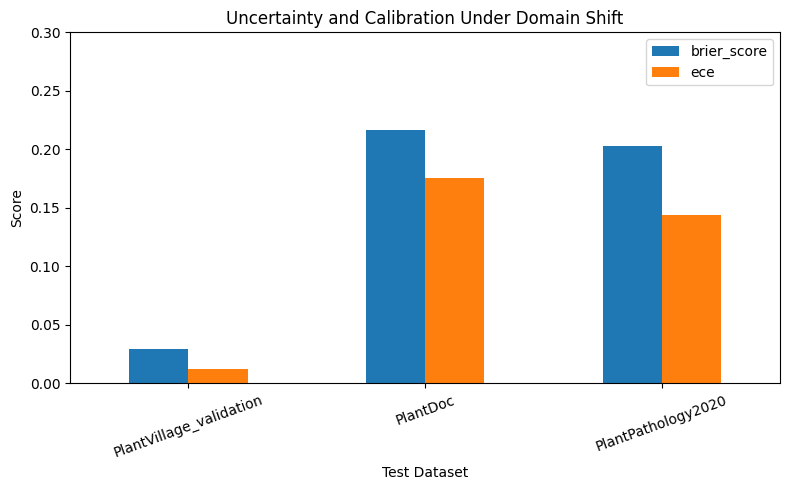

Figure saved at: results/mobilenetv3_small_uncertainty_calibration_comparison.png


In [21]:
plot_uncertainty = combined_results.set_index("test_dataset")[["brier_score", "ece"]]

plot_uncertainty.plot(kind="bar", figsize=(8, 5))

plt.title("Uncertainty and Calibration Under Domain Shift")
plt.xlabel("Test Dataset")
plt.ylabel("Score")
plt.ylim(0, 0.30)
plt.xticks(rotation=20)
plt.tight_layout()

figure_path = "results/mobilenetv3_small_uncertainty_calibration_comparison.png"
plt.savefig(figure_path, dpi=300)

plt.show()

print("Figure saved at:", figure_path)